# **Assignment**

In [ ]:
#Librerie
import zipfile
import os
import matplotlib.pyplot as plt
from google.colab import drive
import numpy as np
import cv2
import os
import torch
import torchvision

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(DEVICE)

cuda


# **CNN**

In [ ]:
import gdown
import zipfile

file_id = "1LJKe_YyvGBaMISB-7m7cW0lzq7f7Isz6"
url = f"https://drive.google.com/uc?id={file_id}"
output = "250711-galaxies.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile("250711-galaxies.zip", 'r') as zip_ref:
    zip_ref.extractall()

!rm 250711-galaxies.zip


Downloading...
From (original): https://drive.google.com/uc?id=1LJKe_YyvGBaMISB-7m7cW0lzq7f7Isz6
From (redirected): https://drive.google.com/uc?id=1LJKe_YyvGBaMISB-7m7cW0lzq7f7Isz6&confirm=t&uuid=206e5e5e-e34e-41ee-bf88-4b8623784895
To: /content/250711-galaxies.zip
100%|██████████| 55.4M/55.4M [00:01<00:00, 34.9MB/s]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import numpy as np
import multiprocessing

# Configurazione
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "./galaxies"
NUM_CLASSES = 4
EPOCHS_PHASE1 = 3
EPOCHS_PHASE2 = 12
CONFIG_NAME = "CNN_finetuning"
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# Calcola il numero ottimale di worker
NUM_WORKERS = min(4, max(1, multiprocessing.cpu_count() - 1))
print(f"Utilizzo {NUM_WORKERS} worker per il DataLoader")

Utilizzo 1 worker per il DataLoader


In [ ]:
# Creazione modello
def create_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, NUM_CLASSES)
    )
    return model.to(DEVICE)

# Funzioni di valutazione
def evaluate(model, data_loader, criterion=None):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)

            if criterion:
                loss = criterion(outputs, labels)
                total_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / total if criterion else None
    return accuracy, avg_loss

In [ ]:
# Funzione di plot
def plot_metrics(train_losses, test_losses, train_accuracies, test_accuracies):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4.5), dpi=150)

    # Loss
    axs[0].plot(train_losses, label="Train Loss", color='blue')
    axs[0].plot(test_losses, label="Test Loss", color='orange')
    axs[0].axvline(x=EPOCHS_PHASE1, color='red', linestyle='--', label='Fine-Tuning')
    axs[0].set_title("Loss", fontsize=18)
    axs[0].set_xlabel("Epoch", fontsize=18)
    axs[0].set_ylabel("Loss", fontsize=18)
    axs[0].legend()
    axs[0].grid(True)

    # Accuracy
    axs[1].plot(train_accuracies, label="Train Accuracy", color='green')
    axs[1].plot(test_accuracies, label="Test Accuracy", color='red')
    axs[1].axvline(x=EPOCHS_PHASE1, color='red', linestyle='--', label='Fine-Tuning')
    axs[1].set_title("Accuracy", fontsize=18)
    axs[1].set_xlabel("Epoch", fontsize=18)
    axs[1].set_ylabel("Accuracy (%)", fontsize=18)
    axs[1].legend()
    axs[1].grid(True)

    plt.suptitle(f"Learning Dynamics - {CONFIG_NAME}", fontsize=18)
    plt.tight_layout()
    plot_path = os.path.join(results_dir, "metrics_plot.jpg")
    plt.savefig(plot_path)
    plt.show()

In [ ]:
# Addestramento modificato
def train_with_finetuning(model, train_loader, test_loader):
    criterion = nn.CrossEntropyLoss()
    train_losses, test_losses = [], []
    train_accuracies, test_accuracies = [], []

    # FASE 1: Training classificatore
    print("\n=== FASE 1: Training Classificatore ===")
    optimizer = optim.Adam(model.fc.parameters(), lr=0.01)

    for epoch in range(EPOCHS_PHASE1):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = epoch_train_loss / total_train
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        test_accuracy, test_loss = evaluate(model, test_loader, criterion)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f"Epoch {epoch+1}/{EPOCHS_PHASE1}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
        print(f"  Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

    # FASE 2: Fine-tuning
    print("\n=== FASE 2: Fine-Tuning ===")
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.layer3.parameters():
        param.requires_grad = True

    optimizer = optim.Adam([
        {'params': model.fc.parameters(), 'lr': 0.001},
        {'params': model.layer4.parameters(), 'lr': 0.0001},
        {'params': model.layer3.parameters(), 'lr': 0.0001}
    ], weight_decay=0.001)

    for epoch in range(EPOCHS_PHASE2):
        model.train()
        epoch_train_loss = 0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = epoch_train_loss / total_train
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        test_accuracy, test_loss = evaluate(model, test_loader, criterion)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f"Epoch {EPOCHS_PHASE1+epoch+1}/{EPOCHS_PHASE1+EPOCHS_PHASE2}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}%")
        print(f"  Test Loss: {test_loss:.4f} | Test Acc: {test_accuracy:.2f}%")

    plot_metrics(train_losses, test_losses, train_accuracies, test_accuracies)
    return model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

def create_carrot_cake_cmap():
    """Crea e restituisce la colormap personalizzata."""
    colors = ["#FFF4E0", "#FFC999", "#FFA857", "#E68A2E", "#B35900"]
    return LinearSegmentedColormap.from_list("carrot_cake", colors)

def setup_confusion_matrix_plot(cm_norm, cm, classes, title):
    """Configura l'aspetto base della matrice di confusione."""
    fig, ax = plt.subplots(figsize=(7, 7))

    # Disegna matrice
    im = ax.imshow(cm_norm, cmap=create_carrot_cake_cmap(), vmin=0, vmax=1)

    # Griglia e assi
    n_classes = len(classes)
    ax.set_xticks(np.arange(-0.5, n_classes, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_classes, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=0.3, alpha=0.3)

    # Etichette
    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    ax.set_xticklabels(classes, rotation=90, fontsize=10)
    ax.set_yticklabels(classes, fontsize=10)
    ax.set_xlabel('Predicted', fontsize=14)
    ax.set_ylabel('True', fontsize=14)

    # Barra dei colori
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label('Accuracy per classe', fontsize=10)

    # Aggiungi valori
    add_matrix_values(ax, cm_norm, cm)

    # Evidenzia errori
    highlight_misclassifications(ax, cm, n_classes)

    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    return fig, ax

def add_matrix_values(ax, cm_norm, cm):
    """Aggiungi i valori numerici alla matrice."""
    threshold = 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm_norm[i, j] > threshold else "black"
            text = f"{cm[i, j]:,}"
            ax.text(j, i, text, ha='center', va='center', color=color, fontsize=10)

def highlight_misclassifications(ax, cm, n_classes):
    """Evidenzia le celle di misclassificazione."""
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j and cm[i, j] > 0:
                ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1,
                            fill=False, edgecolor='red',
                            linewidth=1, linestyle='--', alpha=0.7))

def plot_confusion_matrix(cm, classes, filename):
    """Visualizza la matrice di confusione base."""
    cm_norm = cm.float() / cm.sum(1, keepdim=True).clamp(min=1e-6).cpu().numpy()
    setup_confusion_matrix_plot(cm_norm, cm.cpu().numpy(), classes, "Confusion Matrix")
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    plt.show()

def plot_confusion_matrix_perc(cm, classes, filename):
    """Visualizza la matrice di confusione normalizzata per riga."""
    cm_norm = cm.float() / cm.sum(1, keepdim=True).clamp(min=1e-6).cpu().numpy()
    setup_confusion_matrix_plot(cm_norm, cm.cpu().numpy(), classes, "Confusion Matrix (Row-normalized)")
    plt.savefig(filename, bbox_inches='tight', dpi=150)
    plt.show()

In [ ]:
def compute_mean_std(loader):
    sum_rgb = torch.zeros(3)
    sum_squared_rgb = torch.zeros(3)
    num_pixels = 0

    for data, _ in loader:
        b, c, h, w = data.shape
        num_pixels += b * h * w
        sum_rgb += data.sum(dim=[0, 2, 3])
        sum_squared_rgb += (data ** 2).sum(dim=[0, 2, 3])

    mean = sum_rgb / num_pixels
    var = (sum_squared_rgb / num_pixels) - (mean ** 2)
    std = torch.sqrt(var)
    return mean.tolist(), std.tolist()

***RGB***

In [ ]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import os


def prepare_data_color_only(data_dir, batch_size=32, num_workers=2):
    # Carica dati con ToTensor SOLO per calcolare media e std
    base_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ])

    train_data_base = datasets.ImageFolder(os.path.join(data_dir, "train"), base_transform)
    train_loader_base = DataLoader(train_data_base, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    # Calcolo media e std RGB dal train_loader_base
    mean, std = compute_mean_std(train_loader_base)
    print(f"Calcolata Media RGB: {mean}")
    print(f"Calcolata Dev. Std RGB: {std}")

    # Ora definisco la trasformazione completa con normalizzazione corretta
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    # Caricamento dataset con trasformazione corretta
    train_data = datasets.ImageFolder(os.path.join(data_dir, "train"), transform)
    test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, test_loader, train_data.classes

1. Preparazione dati...
Calcolata Media RGB: [0.10506552457809448, 0.09305881708860397, 0.07865158468484879]
Calcolata Dev. Std RGB: [0.14485430717468262, 0.12415619939565659, 0.11381343752145767]

2. Creazione modello...


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]



3. Addestramento con fine-tuning...

=== FASE 1: Training Classificatore ===
Epoch 1/3
  Train Loss: 1.0279 | Train Acc: 61.36%
  Test Loss: 0.7377 | Test Acc: 73.10%
Epoch 2/3
  Train Loss: 1.0452 | Train Acc: 65.08%
  Test Loss: 0.8925 | Test Acc: 72.80%
Epoch 3/3
  Train Loss: 1.0613 | Train Acc: 65.24%
  Test Loss: 0.7763 | Test Acc: 72.10%

=== FASE 2: Fine-Tuning ===
Epoch 4/15
  Train Loss: 0.6032 | Train Acc: 77.92%
  Test Loss: 0.4023 | Test Acc: 88.50%
Epoch 5/15
  Train Loss: 0.2889 | Train Acc: 89.48%
  Test Loss: 0.3120 | Test Acc: 90.20%
Epoch 6/15
  Train Loss: 0.1461 | Train Acc: 94.84%
  Test Loss: 0.3373 | Test Acc: 90.10%
Epoch 7/15
  Train Loss: 0.0801 | Train Acc: 97.24%
  Test Loss: 0.4196 | Test Acc: 89.30%
Epoch 8/15
  Train Loss: 0.0598 | Train Acc: 97.90%
  Test Loss: 0.4351 | Test Acc: 89.80%
Epoch 9/15
  Train Loss: 0.0500 | Train Acc: 98.30%
  Test Loss: 0.4987 | Test Acc: 90.20%
Epoch 10/15
  Train Loss: 0.0446 | Train Acc: 98.59%
  Test Loss: 0.5101 | Te

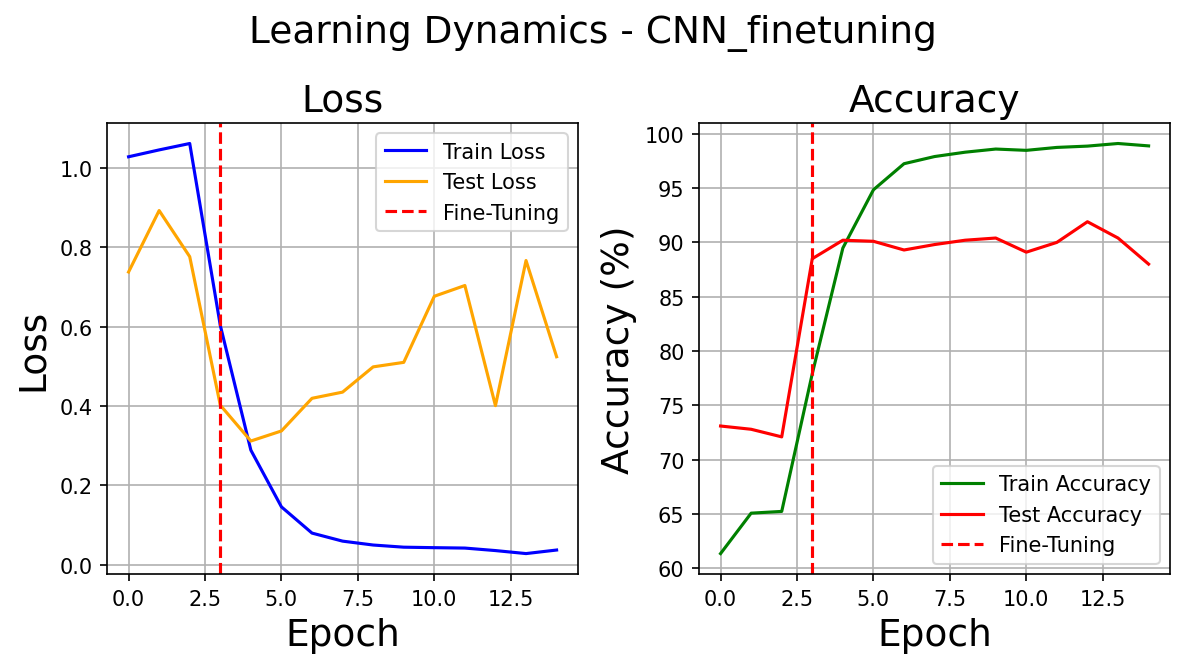


4. Valutazione finale...
Risultati finali - Loss: 0.5242 | Accuracy: 88.00%


In [ ]:
# ESECUZIONE DIRETTA
print("1. Preparazione dati...")
train_loader, test_loader, class_names = prepare_data_color_only(DATA_DIR)

print("\n2. Creazione modello...")
model = create_model()

print("\n3. Addestramento con fine-tuning...")
trained_model = train_with_finetuning(model, train_loader, test_loader)

print("\n4. Valutazione finale...")
final_acc, final_loss = evaluate(trained_model, test_loader, nn.CrossEntropyLoss())
print(f"Risultati finali - Loss: {final_loss:.4f} | Accuracy: {final_acc:.2f}%")



5. Matrice di confusione


/tmp/ipython-input-30-555426835.py:66: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cm_norm = cm.float() / cm.sum(1, keepdim=True).clamp(min=1e-6).cpu().numpy()


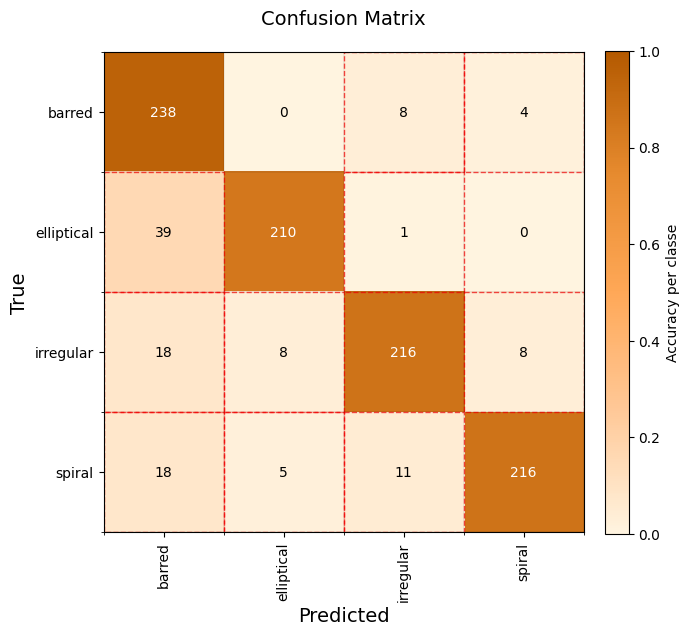

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Funzione per generare la matrice di confusione
def generate_confusion_matrix(model, test_loader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return confusion_matrix(all_labels, all_preds)

# 2. Calcola la matrice di confusione
print("\n5. Matrice di confusione")
cm = generate_confusion_matrix(trained_model, test_loader, NUM_CLASSES)
cm_tensor = torch.from_numpy(cm)  # Converti in tensore per le tue funzioni

# 3. Visualizza le matrici
plot_confusion_matrix(cm_tensor, class_names, "confusion_matrix_CNN_RGB.jpg")


**GRAYSCALE: Baseline**

In [ ]:
def compute_mean_std(loader):
    sum_gray = torch.zeros(1)
    sum_squared_gray = torch.zeros(1)
    num_pixels = 0

    for data, _ in loader:
        # Converti i dati a scala di grigi se necessario (da 3 canali a 1)
        if data.shape[1] == 3:  # Se l'immagine ha 3 canali
            data = data.mean(dim=1, keepdim=True)  # Media tra i canali RGB

        b, c, h, w = data.shape
        num_pixels += b * h * w
        sum_gray += data.sum(dim=[0, 2, 3])
        sum_squared_gray += (data ** 2).sum(dim=[0, 2, 3])

    mean = sum_gray / num_pixels
    var = (sum_squared_gray / num_pixels) - (mean ** 2)
    std = torch.sqrt(var)
    return mean.item(), std.item()


def prepare_data_gray_only(data_dir, batch_size=32, num_workers=2):
    # Trasformazioni base per calcolare mean/std
    base_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.Grayscale(num_output_channels=1),  # Solo 1 canale
        transforms.ToTensor()
    ])

    train_data_base = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=base_transform)
    train_loader_base = DataLoader(train_data_base, batch_size=batch_size, shuffle=True)

    mean, std = compute_mean_std(train_loader_base)
    print(f"Grayscale Mean: {mean:.4f}, Std: {std:.4f}")

    # Trasformazione finale (con 3 canali fake per ResNet)
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.Grayscale(num_output_channels=3),  # Converti a 3 canali per ResNet
        transforms.ToTensor(),
        transforms.Normalize([mean]*3, [std]*3)  # Replica gli stessi valori su tutti i canali
    ])

    train_data = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
    test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform)

    return (
        DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers),
        DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers),
        train_data.classes
    )

1. Preparazione dati...
Grayscale Mean: 0.0951, Std: 0.1280

2. Creazione modello...

3. Addestramento con fine-tuning...

=== FASE 1: Training Classificatore ===
Epoch 1/3
  Train Loss: 1.0984 | Train Acc: 58.82%
  Test Loss: 0.8152 | Test Acc: 68.90%
Epoch 2/3
  Train Loss: 1.1368 | Train Acc: 60.87%
  Test Loss: 0.7800 | Test Acc: 70.80%
Epoch 3/3
  Train Loss: 1.1451 | Train Acc: 61.63%
  Test Loss: 0.9195 | Test Acc: 67.10%

=== FASE 2: Fine-Tuning ===
Epoch 4/15
  Train Loss: 0.6327 | Train Acc: 76.13%
  Test Loss: 0.3986 | Test Acc: 86.80%
Epoch 5/15
  Train Loss: 0.2911 | Train Acc: 89.92%
  Test Loss: 0.3502 | Test Acc: 88.80%
Epoch 6/15
  Train Loss: 0.1420 | Train Acc: 95.20%
  Test Loss: 0.4087 | Test Acc: 88.50%
Epoch 7/15
  Train Loss: 0.0781 | Train Acc: 97.38%
  Test Loss: 0.3861 | Test Acc: 89.10%
Epoch 8/15
  Train Loss: 0.0564 | Train Acc: 98.02%
  Test Loss: 0.3897 | Test Acc: 90.50%
Epoch 9/15
  Train Loss: 0.0468 | Train Acc: 98.49%
  Test Loss: 0.3820 | Test Acc:

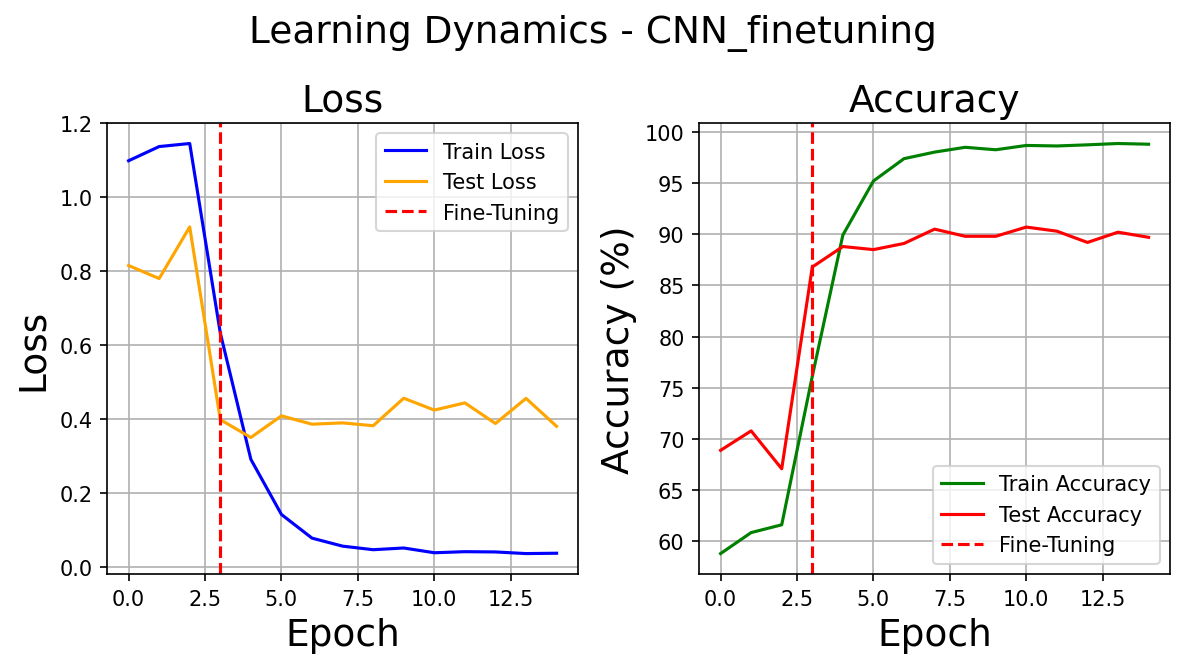


4. Valutazione finale...
Risultati finali - Loss: 0.3804 | Accuracy: 89.70%


In [ ]:
# ESECUZIONE DIRETTA
print("1. Preparazione dati...")
train_loader, test_loader, class_names = prepare_data_gray_only(DATA_DIR)

print("\n2. Creazione modello...")
model = create_model()

print("\n3. Addestramento con fine-tuning...")
trained_model = train_with_finetuning(model, train_loader, test_loader)

print("\n4. Valutazione finale...")
final_acc, final_loss = evaluate(trained_model, test_loader, nn.CrossEntropyLoss())
print(f"Risultati finali - Loss: {final_loss:.4f} | Accuracy: {final_acc:.2f}%")



5. Matrice di confusione


/tmp/ipython-input-30-555426835.py:66: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cm_norm = cm.float() / cm.sum(1, keepdim=True).clamp(min=1e-6).cpu().numpy()


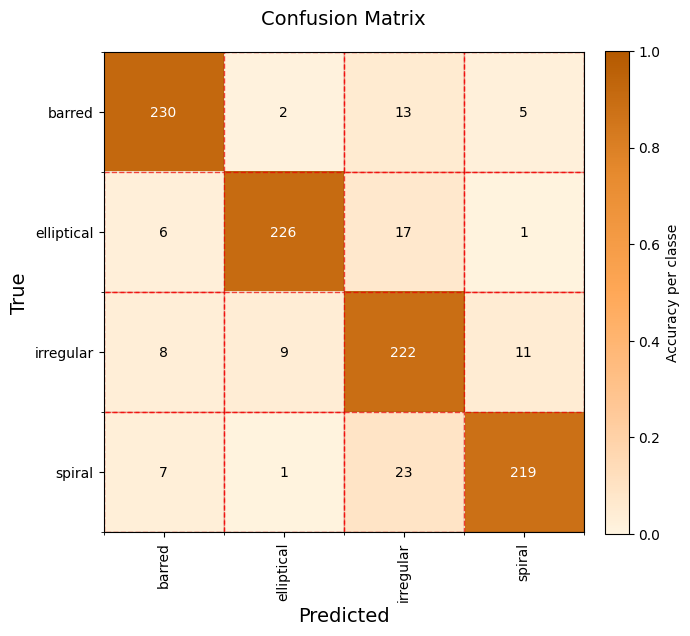

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Funzione per generare la matrice di confusione
def generate_confusion_matrix(model, test_loader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return confusion_matrix(all_labels, all_preds)

# 2. Calcola la matrice di confusione
print("\n5. Matrice di confusione")
cm = generate_confusion_matrix(trained_model, test_loader, NUM_CLASSES)
cm_tensor = torch.from_numpy(cm)  # Converti in tensore per le tue funzioni

# 3. Visualizza le matrici
plot_confusion_matrix(cm_tensor, class_names, "confusion_matrix_Gray.jpg")


***GRAY+INVROT***

In [ ]:
def prepare_data_gray_rotinv(data_dir, batch_size=32, num_workers=2):
    """Prepare grayscale dataset with rotation-invariant augmentations."""
    # 1. Base transform for mean/std calculation
    base_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.Grayscale(num_output_channels=1),  # Process as true grayscale
        transforms.ToTensor()
    ])

    # 2. Load base dataset for statistics
    train_data_base = datasets.ImageFolder(os.path.join(data_dir, "train"), base_transform)
    train_loader_base = torch.utils.data.DataLoader(train_data_base,
                                                  batch_size=batch_size,
                                                  shuffle=False,
                                                  num_workers=num_workers)

    # 3. Compute statistics on single channel (with debug prints)
    print("Calculating mean and std...")
    try:
        mean, std = compute_mean_std(train_loader_base)
        print(f"Successfully computed statistics - Mean: {mean:.4f}, Std: {std:.4f}")
    except Exception as e:
        print(f"Error in compute_mean_std: {str(e)}")
        # Fallback values if computation fails
        mean, std = 0.5, 0.5

    # 4. Define transforms with augmentations
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(360),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),  # Convert to 3 channels
        transforms.Normalize([mean]*3, [std]*3)
    ])

    test_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.Grayscale(num_output_channels=1),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
        transforms.Normalize([mean]*3, [std]*3)
    ])

    # 5. Create final datasets
    train_data = datasets.ImageFolder(os.path.join(data_dir, "train"), train_transform)
    test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), test_transform)

    # 6. Create loaders
    train_loader = torch.utils.data.DataLoader(train_data,
                                             batch_size=batch_size,
                                             shuffle=True,
                                             num_workers=num_workers,
                                             pin_memory=torch.cuda.is_available())

    test_loader = torch.utils.data.DataLoader(test_data,
                                            batch_size=batch_size,
                                            shuffle=False,
                                            num_workers=num_workers,
                                            pin_memory=torch.cuda.is_available())

    return train_loader, test_loader, train_data.classes

In [ ]:
def compute_mean_std(loader):
    sum_gray = torch.zeros(1)
    sum_squared_gray = torch.zeros(1)
    num_pixels = 0

    for data, _ in loader:
        # Debug: print data shape and type
        print(f"Data shape: {data.shape}, Type: {data.dtype}")

        # Ensure we have single channel data
        if data.shape[1] == 3:  # If image has 3 channels
            data = data.mean(dim=1, keepdim=True)  # Convert to grayscale

        b, c, h, w = data.shape
        num_pixels += b * h * w
        sum_gray += data.sum(dim=[0, 2, 3])
        sum_squared_gray += (data ** 2).sum(dim=[0, 2, 3])

    mean = sum_gray / num_pixels
    var = (sum_squared_gray / num_pixels) - (mean ** 2)
    std = torch.sqrt(var)

    print(f"Final computation - Sum: {sum_gray}, Sum Squared: {sum_squared_gray}, Pixels: {num_pixels}")
    return mean.item(), std.item()

1. Preparazione dati...
Calculating mean and std...
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Data shape: torch.Size([32, 1, 224, 224]), Type: torch.float32
Dat

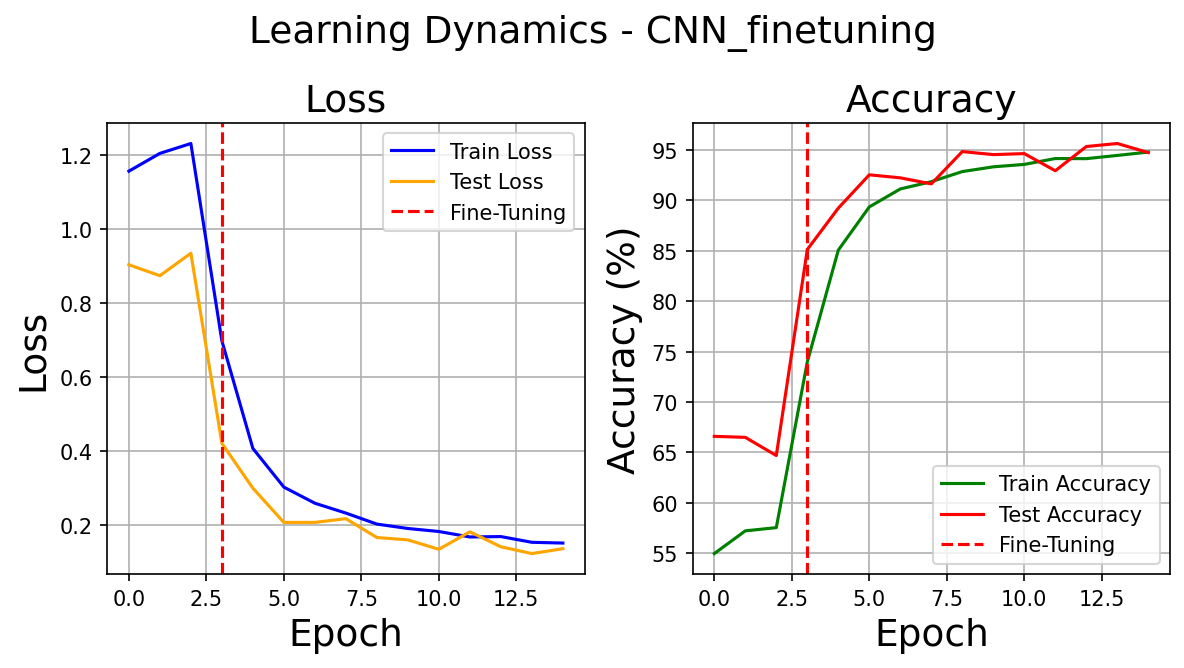


4. Valutazione finale...
Risultati finali - Loss: 0.1349 | Accuracy: 94.70%


In [ ]:
try:
    print("1. Preparazione dati...")
    train_loader, test_loader, class_names = prepare_data_gray_rotinv(DATA_DIR)
    print("\n2. Creazione modello...")
    model = create_model()
    print("\n3. Addestramento con fine-tuning...")
    trained_model = train_with_finetuning(model, train_loader, test_loader)
    print("\n4. Valutazione finale...")
    final_acc, final_loss = evaluate(trained_model, test_loader, nn.CrossEntropyLoss())
    print(f"Risultati finali - Loss: {final_loss:.4f} | Accuracy: {final_acc:.2f}%")
except Exception as e:
    print(f"Errore durante l'esecuzione: {str(e)}")
    import traceback
    traceback.print_exc()

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. Funzione per generare la matrice di confusione
def generate_confusion_matrix(model, test_loader, num_classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return confusion_matrix(all_labels, all_preds)


5. Matrice di confusione


/tmp/ipython-input-30-555426835.py:66: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  cm_norm = cm.float() / cm.sum(1, keepdim=True).clamp(min=1e-6).cpu().numpy()


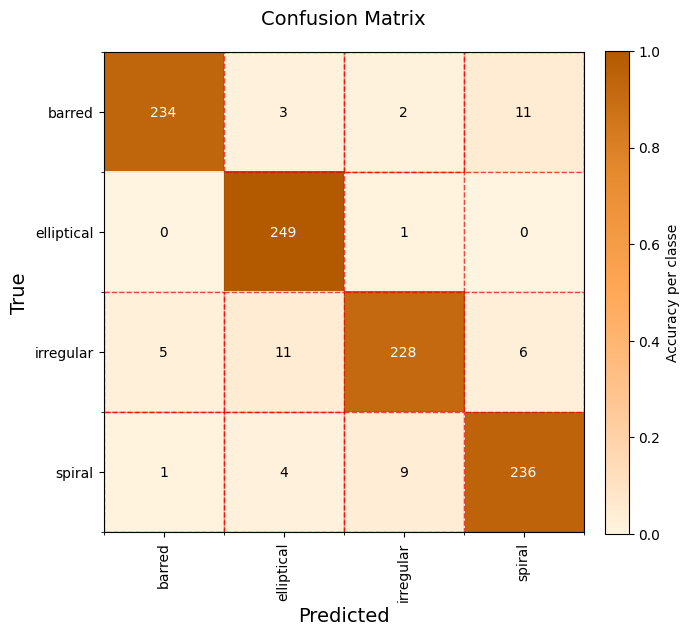

In [ ]:
# 2. Visualizza le matrici
plot_confusion_matrix(cm_tensor, class_names, "confusion_matrix_Gray+invrot.jpg")

In [ ]:
from PIL import Image
import cv2
import numpy as np
from torchvision import transforms

def cartoonize_galaxy(img_pil):
    """Applica effetto cartoon a un'immagine PIL e ritorna PIL."""
    # Converti PIL Image to numpy array (OpenCV usa BGR!)
    img_np = np.array(img_pil)

    # Applica effetto cartoon (blur + edge preservation)
    img_cartoon = cv2.stylization(img_np, sigma_s=150, sigma_r=0.25)

    # Converti nuovamente in PIL Image (RGB)
    return Image.fromarray(img_cartoon)

def get_stylized_transform(mean, std):
    """Restituisce una trasformazione compresa di stilizzazione e normalizzazione."""
    return transforms.Compose([
        transforms.Lambda(lambda x: cartoonize_galaxy(x)),  # Applica cartoonize
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

def prepare_data_stylized(data_dir, batch_size=32, num_workers=2):
    """Carica il dataset e applica la stilizzazione, integrandosi con il notebook esistente."""
    # Step 1: Calcola mean/std sul dataset originale (come nel notebook)
    base_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ])

    train_data_base = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=base_transform)
    train_loader_base = torch.utils.data.DataLoader(train_data_base, batch_size=batch_size, shuffle=True)

    mean, std = compute_mean_std(train_loader_base)
    print(f"Media RGB: {mean}, Deviazione Std: {std}")

    # Step 2: Definisci la trasformazione con stilizzazione
    stylized_transform = get_stylized_transform(mean, std)

    # Step 3: Carica i dataset con la nuova trasformazione
    train_data = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=stylized_transform)
    test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=stylized_transform)

    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_loader, test_loader, train_data.classes

1. Preparazione dati...
Media RGB: [0.10506556183099747, 0.09305873513221741, 0.07865156978368759], Deviazione Std: [0.14485430717468262, 0.12415622174739838, 0.11381345987319946]


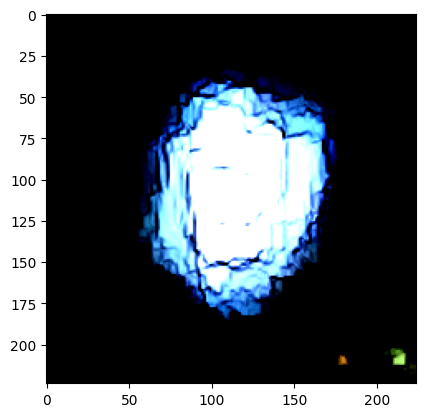

In [ ]:
print("1. Preparazione dati...")
train_loader, test_loader, class_names = prepare_data_stylized(DATA_DIR)
# Esempio di visualizzazione
img, label = next(iter(train_loader))
plt.axis('Off')
plt.imshow(img[0].permute(1, 2, 0))  # Mostra la prima immagine cartoonizzata
plt.show()

In [ ]:
print("\n2. Creazione modello...")
model = create_model()

print("\n3. Addestramento con fine-tuning...")
trained_model = train_with_finetuning(model, train_loader, test_loader)


2. Creazione modello...


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]



3. Addestramento con fine-tuning...

=== FASE 1: Training Classificatore ===
Epoch 1/3
  Train Loss: 0.9212 | Train Acc: 64.43%
  Test Loss: 0.6415 | Test Acc: 77.40%


KeyboardInterrupt: 